# Taller: Árboles de Decisión y Explicabilidad

## 1. Introducción

Los árboles de decisión son uno de los modelos más simples y a la vez más interpretables en el aprendizaje automático. Funcionan como un conjunto de reglas clínicas: cada nodo representa una pregunta binaria sobre una variable (por ejemplo, ¿glucosa > 126 mg/dl?), y al descender por las ramas se llega a una predicción final ￼.

Su atractivo principal es la transparencia: permiten entender con claridad por qué un paciente fue clasificado como “sano” o “enfermo”. Por ejemplo:
  * Si glucosa > 126 mg/dl → probable diabetes.
  * Si glucosa ≤ 126 mg/dl y IMC > 30 → riesgo metabólico.

Además de ser intuitivos, los árboles permiten visualizar la jerarquía de decisiones, extraer reglas concretas y justificar cada predicción, lo que los hace especialmente útiles en aplicaciones médicas, donde la explicabilidad y confianza clínica son tan importantes como la exactitud del modelo ￼.

En este taller trabajaremos con árboles de decisión aplicados a datos de salud, explorando tanto su construcción como las herramientas de interpretación que facilitan su uso en contextos reales.

## 2. Objetivos
 1. Carga y exploración de datos (ENS): seleccionar una variable binaria (ej. diabetes) como objetivo de clasificación.
 2. Entrenamiento de un Árbol de Decisión: comprender la lógica de división en nodos y hojas.
 3. Visualización del árbol: interpretar gráficamente las reglas de decisión.
 4. Explicación en texto: extraer las reglas del árbol en formato “if–then”.
 5. Explicabilidad local: analizar cómo un paciente específico recorre el árbol hasta llegar a su diagnóstico.
 6. Métricas de desempeño: evaluar sensibilidad, especificidad, F1 y ROC para comprender la utilidad clínica del modelo.


## 3. Dataset
La **Encuesta Nacional de Salud (ENS) 2016-2017** es un estudio representativo de la población chilena que recopila información sobre salud, estilo de vida y uso de servicios sanitarios. En este taller utilizaremos un subconjunto de estas variables para aplicar modelos estadísticos sobre datos reales de salud pública. Los datos son de acceso público y están disponibles [aquí](https://data.mendeley.com/datasets/3myh3nzcy3/1).

<div style="text-align:center;">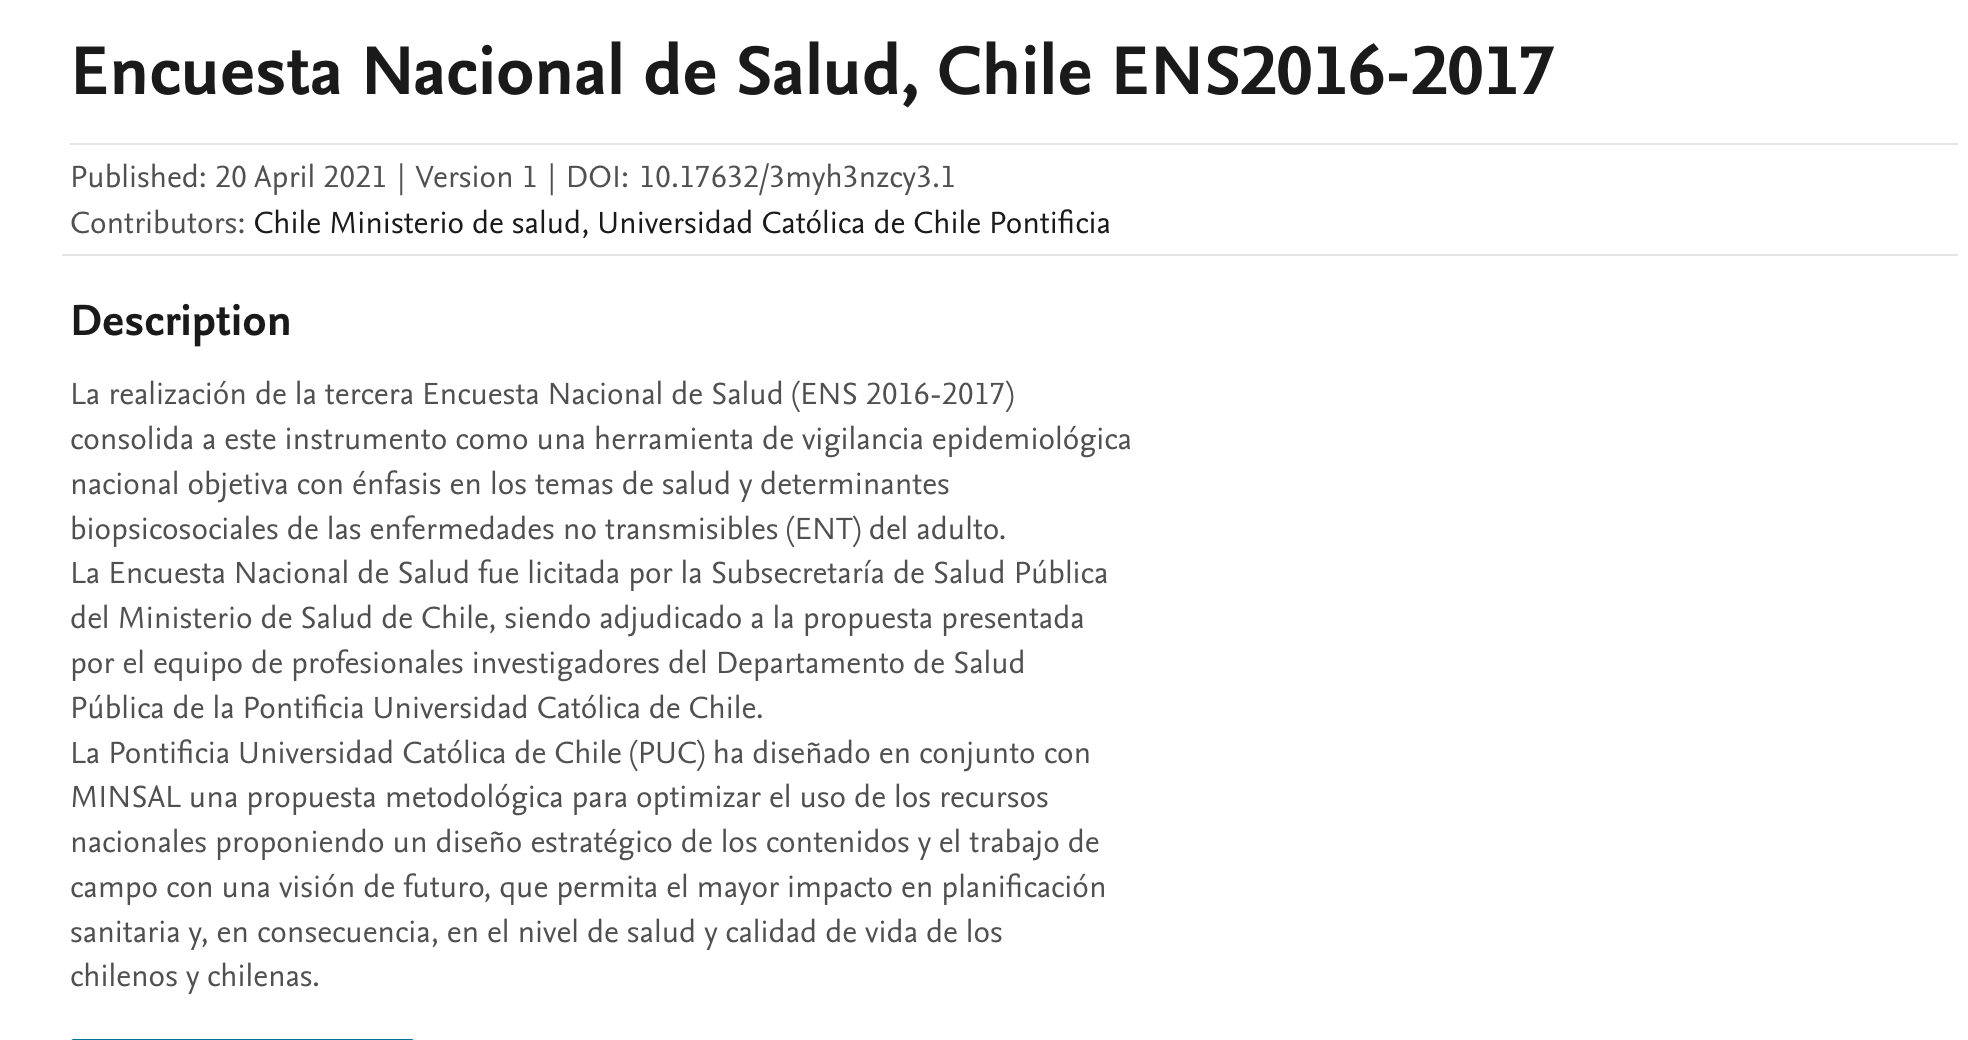</div>

### 3.1 Carga de datos
Tal como se realizo en tallares anteriores, se descargara la base de datos utilizando `wget` y luego se cargara la base de datos en la variable `ens` utilizando la función de pandas `read_spss`.  







In [2]:
# Descargar ENS
!wget https://github.com/iHealthInstitute/Talleres_Diplomado_iHealth/raw/refs/heads/main/data/ENS2016-2017.sav

--2025-09-05 10:51:49--  https://github.com/iHealthInstitute/Talleres_Diplomado_iHealth/raw/refs/heads/main/data/ENS2016-2017.sav
Resolviendo github.com (github.com)... 4.228.31.150
Conectando con github.com (github.com)[4.228.31.150]:443... conectado.
Petición HTTP enviada, esperando respuesta... 302 Found
Localización: https://raw.githubusercontent.com/iHealthInstitute/Talleres_Diplomado_iHealth/refs/heads/main/data/ENS2016-2017.sav [siguiendo]
--2025-09-05 10:51:50--  https://raw.githubusercontent.com/iHealthInstitute/Talleres_Diplomado_iHealth/refs/heads/main/data/ENS2016-2017.sav
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.110.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 34441286 (33M) [application/octet-stream]
Grabando a: «ENS2016-2017.sav»

ENS2016-2017.sav    100%[==================

### 3.2 Librerias necesarias
Se importan las librerías necesarias para el análisis y modelado de datos.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 4. Clasificación con Árboles de Decisión


Los árboles de decisión son algoritmos de clasificación supervisada que funcionan a partir de una serie de preguntas binarias sobre las variables disponibles. Cada división del árbol intenta separar lo mejor posible las clases, reduciendo la mezcla de pacientes en cada nodo (impureza).
  * En cada nodo interno se plantea una condición (por ejemplo, ¿edad > 50 años?).
  * Dependiendo de la respuesta (sí/no), el paciente avanza hacia una rama del árbol.
  * Este proceso continúa hasta llegar a una hoja, donde se asigna una clase final (ejemplo: “diabetes = sí”).

Ventajas en salud:
  * Interpretabilidad: se pueden extraer reglas claras en formato if–then.
  * Transparencia clínica: permiten justificar las predicciones a médicos y pacientes.
  * Flexibilidad: pueden manejar variables numéricas y categóricas sin necesidad de transformaciones complejas.

Limitaciones:
  * Sobreajuste: si el árbol crece demasiado, puede memorizar los datos de entrenamiento y perder capacidad de generalización.
  * Inestabilidad: pequeños cambios en los datos pueden generar estructuras de árbol muy diferentes.

Por estas razones, es común limitar la profundidad del árbol, buscando un balance entre interpretabilidad y rendimiento.

En este taller entrenaremos árboles de decisión sobre la ENS 2016-2017, visualizaremos su estructura y aprenderemos a explicar cómo llegan a sus clasificaciones.



#### **Ejercicio 1** 
1. Carga la base de datos. HINT: usa pandas.read_spss.
2. Seleccionar la variable `di3` (diagnóstico de diabetes) y limpia sus valores para que solo contenga 0 (no diabetes) y 1 (diabetes).
3. Explorar el dataset:
    * Mostrar dimensiones (.shape).
    * Revisar tipos de variables (.dtypes).
    * Calcular prevalencia de la variable objetivo.
4. Identificar y reportar el porcentaje de valores faltantes por columna.
5. Elimina todas las variables con más del 20% de valores faltantes o de tipo distinto a numérico.
6. Elimina todas las filas con valores faltantes
7. Reporta la distribución de la variable objetivo en la base limpia.
Responde:
    - ¿Cuántas filas y columnas tiene la base limpia?
    - ¿Cuál es la prevalencia de diabetes en la base limpia?


In [49]:
# <CODE> 1. Cargar base
ens = pd.read_spss("ENS2016-2017.sav")

# <CODE> 2. Variable objetivo `di3`
print(ens['di3'].value_counts())
# Convertir Si/No a 1/0
ens['di3'] = ens['di3'].map({'NO': 0, 'SÍ': 1})
print(ens['di3'].value_counts())

# <CODE> 3. Explorar dataset
# Dimensiones
print("Dimensiones:", ens.shape)
# Tipos de variables
print("Tipos de variables:\n", ens.dtypes)
# Prevalencia de diabetes
prevalencia_diabetes = ens['di3'].mean()
print("Prevalencia de diabetes:", prevalencia_diabetes)

# <CODE> 4. Valores faltantes
missing_percent = ens.isnull().mean() * 100
print("Porcentaje de valores faltantes por columna:\n", missing_percent[missing_percent > 0])

# <CODE> 5. Eliminar variables con >20% faltantes o de tipo distinto a numerorico
ens = ens.loc[:, missing_percent <= 20]
ens = ens.select_dtypes(exclude=['object', 'category', 'string'])
print("Dimensiones después de eliminar variables con >20% faltantes o de tipo distinto a numérico:", ens.shape)

# <CODE> 6. Eliminar filas con NA 
ens = ens.dropna()
print("Dimensiones después de eliminar filas con NA:", ens.shape)

# <CODE> 7. Distribución de diabetes en la base limpia
print("Distribución de diabetes en la base limpia:\n", ens['di3'].value_counts(normalize=True))


di3
NO             5294
SÍ              886
NO RECUERDO      53
Name: count, dtype: int64
di3
0.0    5294
1.0     886
Name: count, dtype: int64
Dimensiones: (6233, 1165)
Tipos de variables:
 IdEncuesta                       float64
FechaInicioF1                    float64
Region                          category
Comuna                            object
Zona                            category
                                  ...   
Cantidad_sintomas_depresivos     float64
Arsenico_µgL                    category
Cadmio_µgL                      category
Mercurio_µgL                    category
Plomo_µgdL                      category
Length: 1165, dtype: object
Prevalencia de diabetes: 0.14336569579288025
Porcentaje de valores faltantes por columna:
 c2                              97.577411
c2a                             97.577411
c2b                             97.577411
c5b                             99.727258
c7_0_niño                       82.063212
                             

#### **Ejercicio 2** 
 1. Dividir los datos en train/test (80% / 20%). HINT: usa `train_test_split` de sklearn.
 2. Entrenar un `DecisionTreeClassifier` limitando la profundidad (max_depth=3) y el mínimo de muestras por hoja (min_samples_leaf=20).
 3. Reportar métricas de desempeño con `classification_report`.

Responde: 
 * ¿qué significa limitar la profundidad y el mínimo de pacientes por hoja?
 * ¿qué métricas son más relevantes en este caso y por qué?
 * ¿cómo se comporta el modelo en train y en test? ¿hay sobreajuste?
 * ¿Qué sucede al cambiar max_depth y min_samples_leaf? 

In [93]:
# <CODE> 1. Dividir los datos en train/test (80% / 20%)
from sklearn.model_selection import train_test_split

# Separar variables predictoras y objetivo
X = ens.drop(columns=['di3'])
y = ens['di3']

# División estratificada para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (3393, 35)
Tamaño prueba: (849, 35)


In [105]:
# <CODE> 2. Entrenar un DecisionTreeClassifier limitando la profundidad (max_depth=4) y el mínimo de muestras por hoja (min_samples_leaf=20).

from sklearn.tree import DecisionTreeClassifier

# Definir clasificador con restricciones
clf = DecisionTreeClassifier(
    max_depth=3, 
    min_samples_leaf=20,
    random_state=42
)

# Combinar preprocesamiento + modelo en un pipeline
from sklearn.pipeline import Pipeline
tree_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", clf)
])

# Entrenar
tree_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [106]:
# <CODE> 3. Reportar métricas de desempeño con classification_report.
from sklearn.metrics import classification_report

# Predicciones en test
y_pred = tree_model.predict(X_test)

# Reporte de métricas
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

         0.0      0.915     0.961     0.938       726
         1.0      0.674     0.472     0.555       123

    accuracy                          0.890       849
   macro avg      0.795     0.716     0.746       849
weighted avg      0.880     0.890     0.882       849



#### **Ejercicio 3** 

1. Visualizar el árbol con plot_tree de sklearn, mostrando:
    * Variables usadas en los nodos.
    * Valores de probabilidad de cada clase en las hojas.
    * Colores que indiquen la clase predominante.
2. Exportar las reglas en formato de texto usando export_text.
3. Identificar al menos tres reglas clínicas del árbol y expresarlas en formato if–then:
    * Ejemplo: “Si glucosa > 126 y edad > 60 → mayor probabilidad de diabetes”.

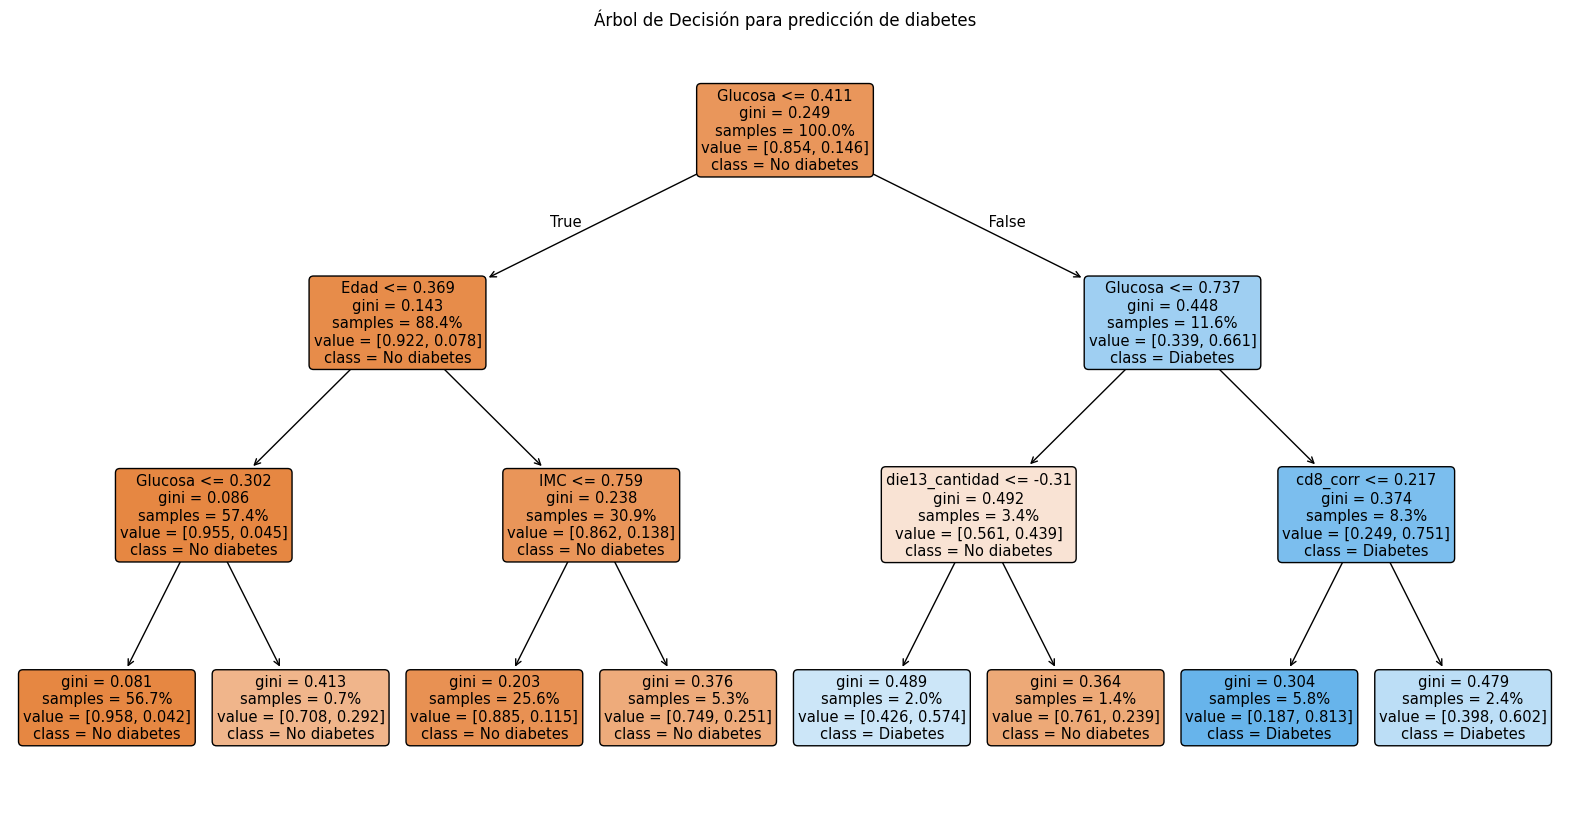

In [107]:
# <CODE> 1. Visualizar el árbol con plot_tree

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extraer el clasificador entrenado (árbol puro, sin el preprocesamiento)
clf_trained = tree_model.named_steps["classifier"]

# Ajustamos el preprocesador para obtener nombres de variables transformadas
preprocessor.fit(X_train, y_train)

# Obtener nombres de features (numéricas + categóricas codificadas)
feature_names = X.columns.tolist()

plt.figure(figsize=(20,10))
plot_tree(
    clf_trained,
    feature_names=feature_names,
    class_names=["No diabetes", "Diabetes"],
    filled=True,
    proportion=True,
    rounded=True
)
plt.title("Árbol de Decisión para predicción de diabetes")
plt.show()

In [108]:
# <CODE> 2. Exportar las reglas en formato de texto usando export_text.
from sklearn.tree import export_text

# Exportar las reglas en formato "if–then"
rules = export_text(clf_trained, feature_names=list(feature_names))
print(rules)

|--- Glucosa <= 0.41
|   |--- Edad <= 0.37
|   |   |--- Glucosa <= 0.30
|   |   |   |--- class: 0.0
|   |   |--- Glucosa >  0.30
|   |   |   |--- class: 0.0
|   |--- Edad >  0.37
|   |   |--- IMC <= 0.76
|   |   |   |--- class: 0.0
|   |   |--- IMC >  0.76
|   |   |   |--- class: 0.0
|--- Glucosa >  0.41
|   |--- Glucosa <= 0.74
|   |   |--- die13_cantidad <= -0.31
|   |   |   |--- class: 1.0
|   |   |--- die13_cantidad >  -0.31
|   |   |   |--- class: 0.0
|   |--- Glucosa >  0.74
|   |   |--- cd8_corr <= 0.22
|   |   |   |--- class: 1.0
|   |   |--- cd8_corr >  0.22
|   |   |   |--- class: 1.0



#### **Ejercicio 4** 

1. Calcular matriz de confusión con confusion_matrix. Hint: puede usar `confusion_matrix` y `ConfusionMatrixDisplay` de sklearn.
2. Derivar métricas clínicas clave:
    * Sensibilidad (Recall).
    * Especificidad.
    * Precisión.
    * F1-score.
3. Graficar la curva ROC y calcular el AUC. Hint: puede usar `roc_curve` y `roc_auc_score` de sklearn
4. Responda: ¿qué métrica es más relevante en un contexto de salud pública (ejemplo: detección de diabetes)?

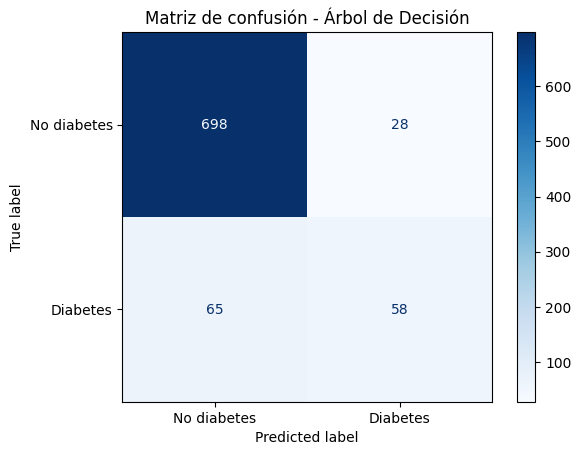

Matriz de confusión:
 [[698  28]
 [ 65  58]]


In [118]:
# <CODE> 1. Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones en el set de prueba
y_pred = tree_model.predict(X_test)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No diabetes", "Diabetes"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Árbol de Decisión")
plt.show()

print("Matriz de confusión:\n", cm)

In [119]:
# <CODE> 2. Métricas derivadas de la matriz de confusión
# Extraer VP, FN, FP, VN
tn, fp, fn, tp = cm.ravel()

# Sensibilidad (Recall)
sensibilidad = tp / (tp + fn)

# Especificidad
especificidad = tn / (tn + fp)

# Precisión
precision = tp / (tp + fp)

# F1-score
f1 = 2 * (precision * sensibilidad) / (precision + sensibilidad)

print(f"Sensibilidad (Recall): {sensibilidad:.3f}")
print(f"Especificidad: {especificidad:.3f}")
print(f"Precisión: {precision:.3f}")
print(f"F1-score: {f1:.3f}")

Sensibilidad (Recall): 0.472
Especificidad: 0.961
Precisión: 0.674
F1-score: 0.555


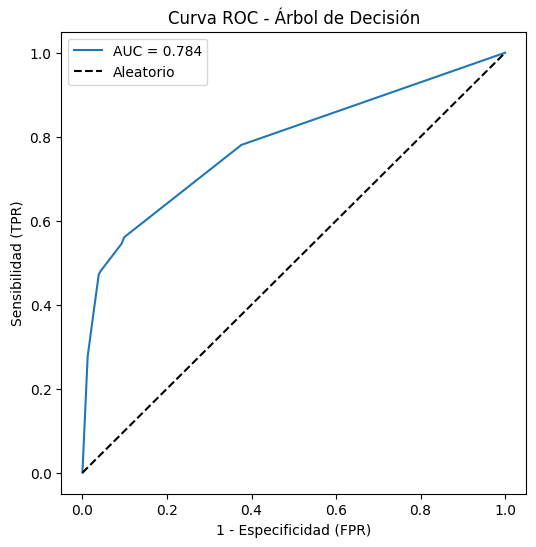

In [120]:
# <CODE> 3. Curva ROC y AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades para clase positiva (diabetes=1)
y_proba = tree_model.predict_proba(X_test)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Aleatorio")
plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (TPR)")
plt.title("Curva ROC - Árbol de Decisión")
plt.legend()
plt.show()

#### **Ejercicio 5** 
1.	Entrenar varios árboles variando la profundidad (max_depth = 2, 4, 6, 10).
2.	Para cada árbol, calcular ROC-AUC en test y graficar los resultados.
3.	Identificar en qué punto aparece sobreajuste (cuando el rendimiento en train es mucho mayor que en test).
4.	Comparar las reglas extraídas de un árbol muy simple (profundidad=2) con las de uno más complejo (profundidad=10).
5.	Reflexión: ¿qué balance prefieres en medicina: un modelo más explicable o uno más preciso?